## Koppen-geiger analyser WIP

In [1]:
# setup imports
import sys
from pathlib import Path


from tqdm.notebook import tqdm

from koppen_geiger import (
    KOPPEN_DESCRIPTION,
    analyse_koppen_geiger,
    load_koppen_pickles_from_folder,
    plot_climate_class_timeseries,
)


# Options before running

In [ ]:
# folder with shapefiles
SHAPEFILE_PATH = Path.cwd()/"shapefiles"

# folder with raster files
# download from https://www.gloh2o.org/koppen/
KOPPEN_GEIGER = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/koppen_geiger_tif" )

# base folder for saving outputs
KOPPEN_FIGURES = Path("/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/figures/koppen_geiger")



# Find all raster files
# can change resolution by changing the filename pattern:
# "koppen_geiger_0p00833333.tif" for 0.00833333 degree resolution (=1 km at equator) 
# or "koppen_geiger_0p5.tif" for 0.5 degree resolution. 0p1.tif for 0.1 degree resolution and 1p0.tif for 1 degree resolution.
files = sorted(KOPPEN_GEIGER.rglob("koppen_geiger_0p00833333.tif"))

# Directories for saving outputs - can change the name to reflect the resolution for example
save_dir = KOPPEN_FIGURES / "test_for_ewc_highres"
save_dir.mkdir(parents=True, exist_ok=True)

In [3]:
# Define shapefiles
# adjust paths if needed
# can also set plotting options here, e.g. edgecolor, linewidth, linestyle, etc.
shapefiles = {
    "test1": {
        "path": SHAPEFILE_PATH / "id_1.shp",
        "edgecolor": "black",
        "linewidth": 2,
        "linestyle": "-",
    },
    "test2": {"path": SHAPEFILE_PATH / "id_2.shp", "edgecolor": "blue", "linewidth": 2},
    "test3": {"path": SHAPEFILE_PATH / "id_5.shp", "edgecolor": "red", "linewidth": 2},
}


## per shapefile

creates a folder per shapefile

In [4]:
for shapename, shp_cfg in tqdm(
    shapefiles.items(), total=len(shapefiles), desc="total koppen-geiger analysis", position=0
):
    shapefile_save_dir = save_dir / shapename
    shapefile_save_dir.mkdir(parents=True, exist_ok=True)

    for path in tqdm(
        files,
        total=len(files),
        desc=f"current shapefile = {shapename}.shp",
        position=1,
        leave=False,  # prevents clutter after finishing inner loop
    ):
        df_percent, top_df = analyse_koppen_geiger(
            path_to_file=path,
            shapefiles={shapename: shp_cfg},
            koppen_description=KOPPEN_DESCRIPTION,
            plot_map=True,
            plot_hist=True,
            generate_table=True,
            save_dir=shapefile_save_dir,
            show_plot=False,
            return_fig=False,
        )

total koppen-geiger analysis:   0%|          | 0/3 [00:00<?, ?it/s]

current shapefile = test1.shp:   0%|          | 0/18 [00:00<?, ?it/s]

current shapefile = test2.shp:   0%|          | 0/18 [00:00<?, ?it/s]

current shapefile = test3.shp:   0%|          | 0/18 [00:00<?, ?it/s]

## all shapefiles combined



In [5]:
shapefile_save_dir = save_dir / "combined"
shapefile_save_dir.mkdir(parents=True, exist_ok=True)

for path in tqdm(
    files,
    total=len(files),
    desc="combined",
):
    df_percent, top_df = analyse_koppen_geiger(
        path_to_file=path,
        shapefiles=shapefiles,
        koppen_description=KOPPEN_DESCRIPTION,
        plot_map=True,
        plot_hist=True,
        generate_table=True,
        save_dir=shapefile_save_dir,
        show_plot=False,
        return_fig=False,
    )

combined:   0%|          | 0/18 [00:00<?, ?it/s]

## example of table and usage of table data

In [6]:
pkl_folder = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/figures/koppen_geiger/test_for_ewc/test3/"
loaded_data = load_koppen_pickles_from_folder(pkl_folder)
loaded_data.tail()

,Plotted Area,test3,climate_class,period,ssp,year_start,year_middle,year_end,description
531,0.0,0.0,Dwb,2071_2099,SSP585,2071,2085,2099,"Snow, dry winter, warm summer"
532,0.0,0.0,Dwc,2071_2099,SSP585,2071,2085,2099,"Snow, dry winter, cold summer"
533,0.0,0.0,Dwd,2071_2099,SSP585,2071,2085,2099,"Snow, dry winter, very cold winter"
539,0.0,0.0,EF,2071_2099,SSP585,2071,2085,2099,Ice cap
538,0.0,0.0,ET,2071_2099,SSP585,2071,2085,2099,Tundra


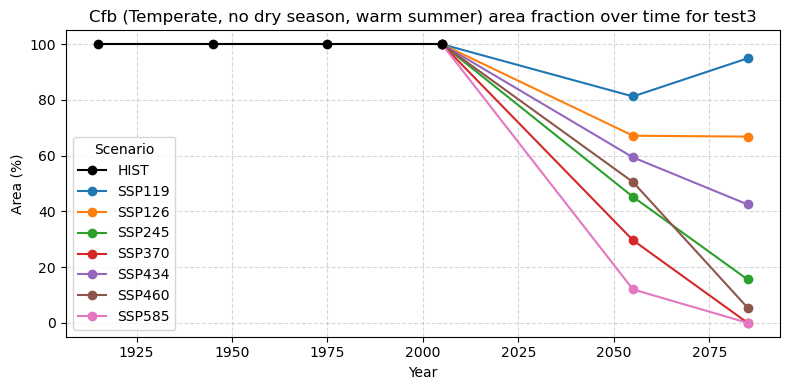

In [7]:
fig, ax = plot_climate_class_timeseries(
    loaded_data,
    column_name="test3",
    climate_class="Cfb",
)